In [1]:
import pyNN.neuron as sim
import matplotlib.pyplot as plt
from pyNN import space
from pyNN.random import RandomDistribution, NumpyRNG
import numpy as np
from pyNN.neuron import Projection, StaticSynapse, FixedNumberPreConnector
import pandas as pd
from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator

/home/tkmcg/neuron-env/lib/python3.12/site-packages/pyNN/neuron/__init__.py:14: UserWarning: mpi4py not available
  warnings.warn("mpi4py not available")


In [2]:
class Ellipse():
    """
    Represents a ellipitical volume within which neurons may be distributed.
    """
    def __init__(self, radius_x, radius_y, radius_z):
        self.radius_x = radius_x
        self.radius_y = radius_y
        self.radius_z = radius_z
                
    def generate_positions(self, n, rotation_angle):
        """Return `n` points distributed randomly with uniform density within the eclipse"""
        num_points = n
        rotation_angle = np.pi/2 - rotation_angle

        x_points = [] 
        y_points = [] 
        z_points = [] 
        
        while len(x_points) < num_points: 
            # Generate a random point inside the sphere 
            theta = np.random.uniform(0, 2 * np.pi) 
            phi = np.random.uniform(0, np.pi) 
            x_radius = self.radius_x*np.cbrt(np.random.uniform(0, 1))  # uniform volume
            y_radius = self.radius_y*np.cbrt(np.random.uniform(0, 1))
            z_radius = self.radius_z*np.cbrt(np.random.uniform(0, 1))
            
            x = float(x_radius * np.sin(phi) * np.cos(theta)) 
            y = float(y_radius * np.sin(phi) * np.sin(theta)) 
            z = float(z_radius * np.cos(phi))

            # Reject if values are outside the ellipse
            # Otherwise, save the point
            if x**2/x_radius**2 + y**2/y_radius**2 + z**2/z_radius**2 > 1:
                continue


            #rotate around the z axis
            x_points.append(x*np.cos(rotation_angle) - y*np.sin(rotation_angle))
            y_points.append(y*np.cos(rotation_angle) + x*np.sin(rotation_angle))
            z_points.append(z)

            points = np.vstack((x_points, y_points, z_points))

        return x_points, y_points, z_points

In [3]:
def set_axes_equal(ax):
    '''Set 3D plot axes to equal scale.'''
    x_limits = ax.get_xlim3d()
    y_limits = ax.get_ylim3d()
    z_limits = ax.get_zlim3d()

    x_range = abs(x_limits[1] - x_limits[0])
    x_middle = np.mean(x_limits)
    y_range = abs(y_limits[1] - y_limits[0])
    y_middle = np.mean(y_limits)
    z_range = abs(z_limits[1] - z_limits[0])
    z_middle = np.mean(z_limits)

    plot_radius = 0.5 * max([x_range, y_range, z_range])

    ax.set_xlim3d([x_middle - plot_radius, x_middle + plot_radius])
    ax.set_ylim3d([y_middle - plot_radius, y_middle + plot_radius])
    ax.set_zlim3d([z_middle - plot_radius, z_middle + plot_radius])

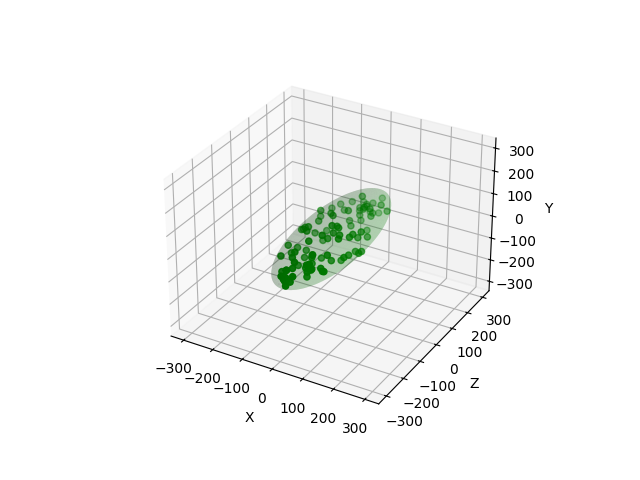

In [56]:
#not useable. class has changed to account for the rotation of the STN
%matplotlib inline
%matplotlib widget
x_radius = 100
y_radius = 100
z_radius = 300
data = Ellipse(x_radius, y_radius, z_radius)
shape = data.generate_positions(100)

xdata = shape[0]
ydata = shape[1]
zdata = shape[2]


# Set of all spherical angles:
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)

# Cartesian coordinates that correspond to the spherical angles:
# (this is the equation of an ellipsoid):
x = x_radius * np.outer(np.cos(u+0.785398), np.sin(v))
y = y_radius * np.outer(np.sin(u+0.785398), np.sin(v))
z = z_radius * np.outer(np.ones_like(u), np.cos(v))


fig = plt.figure()
ax = plt.axes(projection='3d')
ax.set_xlabel('X')
ax.set_ylabel('Z')
ax.set_zlabel('Y')
ax.plot_surface(x, z, y, alpha = 0.15, color = "g")
ax.scatter3D(xdata, zdata, ydata, color = "g")
set_axes_equal(ax)



In [4]:
##### Add in the STN neurons and change the geometry to match the coupling project with DC current ####
v_init = -68
rng_seed = 856
n = 100
rotation_angle = 0.610865

############ Setup the simulation##########
sim.setup(timestep=0.01)


###########set up the neuron type##############
cortical_type = sim.HH_cond_exp()
STN_type = sim.HH_cond_exp()

########## create a population of neurons ###############
cortical_pop = sim.Population(n, cortical_type, initial_values={'v': v_init}, label="Cortical neurons")
STN_pop = sim.Population(n, STN_type, initial_values={'v': v_init}, label="STN neurons")

######## positions of the cells #######################
ellipse = Ellipse(4176,3080 ,2961 )
STN_space = ellipse.generate_positions(n, rotation_angle)

cortical_pop.positions[0], cortical_pop.positions[1],cortical_pop.positions[2] = STN_space[0], STN_space[1], STN_space[2]
STN_pop.positions[0], STN_pop.positions[1],STN_pop.positions[2] = STN_space[0], STN_space[1], STN_space[2]


############ set up the current ##############
start = 600
stop = 1000
cortical_pop.inject(sim.DCSource(start=start, stop=stop, amplitude=1))

############# make the connections ############
syn_CorticalCollateralSTN = StaticSynapse(weight=0.12, delay=1)

prj_CorticalSTN = Projection(
    cortical_pop,
    STN_pop,
    FixedNumberPreConnector(n=5, allow_self_connections=False),
    syn_CorticalCollateralSTN,
    source="collateral(0.5)",
    receptor_type="excitatory",
)

######## Record membrane potential from the STN neurons #############
#cortical_pop.record('v')

STN_pop.sample(10).record('v')

######### Run the simulation ###########
sim.run(1000)
'''
############ Get and plot data ############
data = STN_pop.get_data().segments[0]
vm = data.filter(name="v")[0]

plt.plot(vm.times, vm)
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.title("PyNN simulation (HH neuron)")
plt.show()
'''
####### Clean up ###########
sim.end()

3907.9632089838583


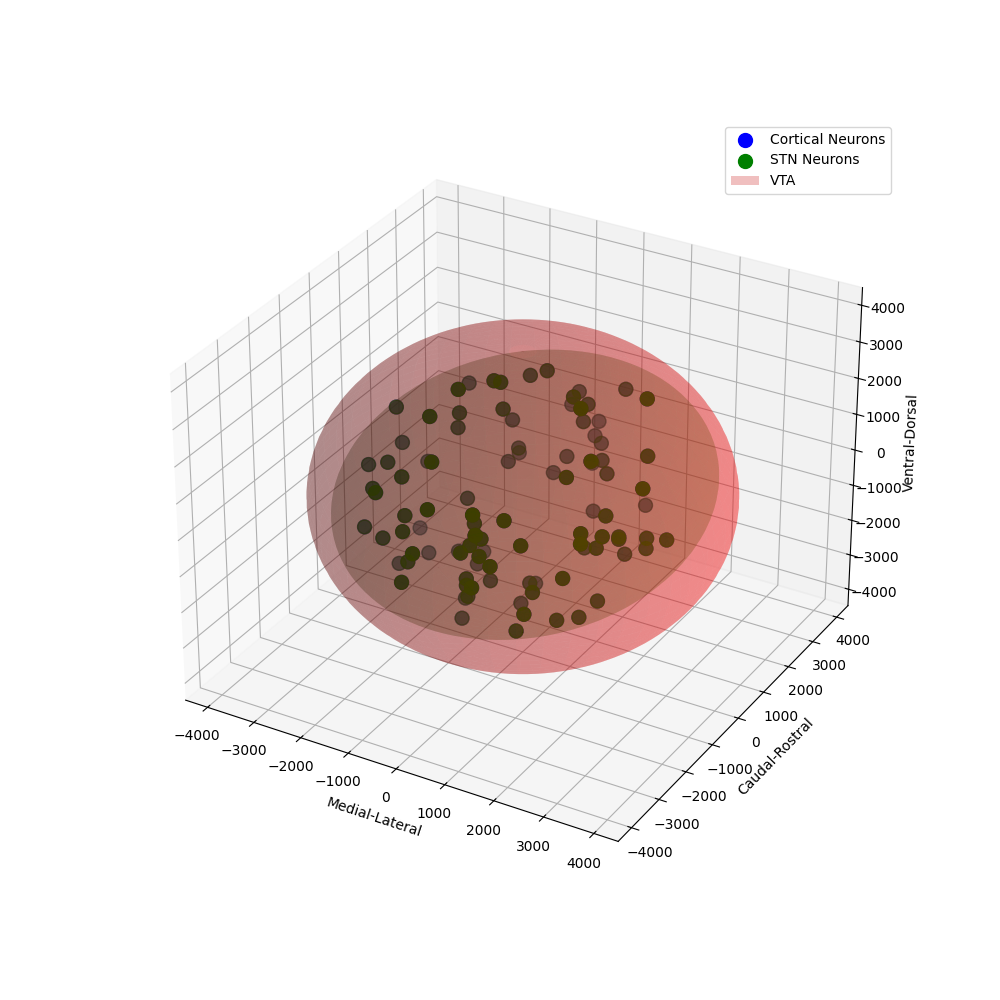

In [5]:
###### plot where the neurons are in the STn space #########
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
%matplotlib widget

################################################
volume_activated_tissue = 2.5e+11 #[6e+9, 10e+9, 15e+9]

##############################################
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('Medial-Lateral')
ax.set_zlabel('Ventral-Dorsal')
ax.set_ylabel('Caudal-Rostral')


##### add in the cortical neurons##############
x_points_clean_ctx = cortical_pop.positions[0]
y_points_clean_ctx = cortical_pop.positions[1]
z_points_clean_ctx = cortical_pop.positions[2]

ax.scatter(x_points_clean_ctx, z_points_clean_ctx, y_points_clean_ctx, c='blue', s=100, label = "Cortical Neurons")

##### add in the STN neurons##########
x_points_clean_stn = STN_pop.positions[0]
y_points_clean_stn = STN_pop.positions[1]
z_points_clean_stn = STN_pop.positions[2]

ax.scatter(x_points_clean_stn, z_points_clean_stn, y_points_clean_stn, c='green', s=100, label = "STN Neurons")

###### add in the electric field ########
theta = np.linspace(0, 2 * np.pi, 100)
phi = np.linspace(0, np.pi, 50)
theta, phi = np.meshgrid(theta, phi)
r_sphere = ((3*volume_activated_tissue)/(4*np.pi))**(1/3)

x_sphere = r_sphere * np.sin(phi) * np.cos(theta)
y_sphere = r_sphere * np.sin(phi) * np.sin(theta)
z_sphere = r_sphere * np.cos(phi)


#Plot ellipsoidal
# Set of all spherical angles:
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 100)

# Cartesian coordinates that correspond to the spherical angles:
# (this is the equation of an ellipsoid):
x = 4176 * np.outer(np.cos(u), np.sin(v))
y = 3080 * np.outer(np.sin(u), np.sin(v))
z = 2961 * np.outer(np.ones_like(u), np.cos(v))

#rotate around the rostral-caudal axis
x_dash = np.cos(0.785398)*x - np.sin(0.785398)*y
y_dash = np.cos(0.785398)*y + np.cos(0.785398)*x

ax.plot_surface(x_dash, z, y_dash, alpha = 0.15, color = "g")
ax.plot_surface(x_sphere, y_sphere, z_sphere, alpha=0.25, color = "r", label = "VTA")
set_axes_equal(ax)

print(r_sphere)

ax.legend()

plt.show()

In [65]:
float(4/3*np.pi*4*3*3)

150.79644737231007